# Clase 9 - Feature Engineering 📎

- MDS7202: Laboratorio de Programación Científica para Ciencia de Datos
- Profesor: Diego Cortez

## Objetivos de la Clase 🎯



- Comprender qué son los métodos de aprendizajes automático.
- Comprender qué son las features en el aprendizaje automático y por qué son importantes.
- Aprender técnicas de selección de características, como la eliminación de características redundantes o irrelevantes.
- Aprender técnicas de transformación de características, como la normalización o la creación de características sintéticas.
- Comprender que las características afectan el rendimiento del modelo y cómo evaluar las características seleccionadas.
- Aprender a aplicar técnicas de feature engineering utilizando Scikit-Learn.

señalar que en la segunda se van a hacer nuevas caracteristicas


## ¿Que es Machine Learning? 🤔

Machine Learning es un subcampo de la inteligencia artificial (IA) que se enfoca en el desarrollo de algoritmos y modelos informáticos que permiten a las computadoras aprender y mejorar automáticamente a través de la experiencia, sin ser programadas explícitamente para realizar tareas específicas.

En lugar de ser programadas con reglas predefinidas, las máquinas de aprendizaje automático pueden aprender y adaptarse a partir de datos de entrada, identificando patrones, haciendo predicciones y tomando decisiones basadas en la información disponible. Estos modelos son entrenados utilizando datos históricos y retroalimentación, y pueden ajustarse y mejorar con el tiempo a medida que se les expone a más datos.

<img src='https://github.com/MDS7202/MDS7202/blob/main/recursos/2023-01/14-Feature-Engineering-Parte-I/machine_learning.png?raw=true' width=700 />


### Esquema General de Machine Learning


#### Unsupervised Learning / Aprendizaje No Supervisado

Técnicas que no requieren datos etiquetados para entrenar modelos predictivos. Dentro de estos algoritmos encontramos los siguientes grupos: 


- **Clustering:** Técnicas para agrupar observaciones por su similitud a través de métricas de distancia (como la distancia euclideana por ejemplo). Permite encontrar grupos que no son claros ante nuestro criterio. Por ejemplo, agrupar clientes según sus características.


- **Reducción de Dimensionalidad:** Conjuntos de técnicas que permiten representar datos en menos dimensiones que las originales. Su utilidad radica tanto en permitir visualizar datos como mejorar el rendimiento de clustering e incluso clasificadores. Ejemplo: Usar T-SNE para proyectar los datos del Better Life Index en dos dimensiones. 

         
<img src='https://miro.medium.com/v2/resize:fit:809/0*tamvSiqDneDfw2Vr' width=800 />            

   
### Supervised Learning / Aprendizaje Supervisado

Técnicas que requieren datos etiquetados para entrenar modelos predictivos. Dentro de estos algoritmos encontramos los siguientes grupos:


- **Clasificación:** Tarea que consiste en predecir una clase/categoría. Ejemplo: Predecir si una persona tiene caries o no a partir de una imagen.


- **Regresión:** Tarea que consiste en predecir un número real. Ejemplo: A partir del registro metereológico, elaborar un clasificador que permita predecir la temperatura de mañana.

<img src='https://github.com/MDS7202/MDS7202/blob/main/recursos/2026-01/09_Feature_engineering/supervised_learning.png?raw=true' width=700 />


> **Pregunta ❓:** ¿Qué necesito para desarrollar un modelo predictivo?

## ¿Qué es Feature Engineering? 🧮



Feature engineering es el proceso de seleccionar, transformar y crear características relevantes de entrada para construir un modelo de aprendizaje automático preciso y eficiente.

> **Pregunta ❓:** ¿Se necesita algún conocimiento previo para realizar Feature Engineering?

## Problema a visitar: House Pricing

![House Pricing](https://storage.googleapis.com/kaggle-media/competitions/House%20Prices/kaggle_5407_media_housesbanner.png)

Fuente: https://www.kaggle.com/c/house-prices-advanced-regression-techniques

Al igual que en la clase anterior, el dataset **`house pricing`** consiste en 80 variables (79 variables explicativas más una variable objetivo) que describen aspectos fundamentales de hogares residenciales en la ciudad de *Ames, Iowa*. 

La variable objetivo es el precio final de cada hogar (regresión)

In [2]:
# Importamos librerías a utilizar en la clase
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm

import plotly.express as px

In [3]:
# El conjunto a trabajar es el de entrenamiento
df = pd.read_csv(
    "https://raw.githubusercontent.com/MDS7202/MDS7202/main/recursos/2023-01/13-EDA//train.csv",
    index_col="Id",
)

> **Actividad 📎**: Imaginen que nos pasan estos datos y nos señalan que el conjunto de datos esta compuesto por:

- Terreno 🏔️
        "LotArea",  # Area del terreno
        "LandSlope",  # Pendiente del terreno
        "Neighborhood",  # Barrio
- Metadatos de la Vivienda 📆
        "BldgType",  # Tipo de vivienda
        "YearBuilt",  # Año de construcción
        "YearRemodAdd",  # Año de remodelación
        "Utilities",  # Agua, luz, etc...
- Materiales 🧱
        "Foundation",  # Fundación de la vivienda
        "RoofMatl",  # Material del techo
        "RoofStyle",  # Estilo del techo
        "Exterior1st",  # Material del Exterior
        "ExterCond",  # Condición del material exterior
- Interior de la casa 🏡
        "GrLivArea",  # Area habitable sobre el nivel del suelo.
        "1stFlrSF",  # Area primer piso
        "2ndFlrSF",  # Area segundo piso
        "FullBath",  # Baños completos
        "HalfBath",  # Baños de visita?
        "BedroomAbvGr",  # Piezas
        "KitchenAbvGr",  # Cocinas
        "KitchenQual",  # Calidad de la cocina
- Sótano 🪨
        "TotalBsmtSF",  # Total sótano
        "BsmtCond",  # Condición del sótano
- Garaje 🚗
        "GarageType",  # Tipo de garaje
        "GarageCars",  # Cantidad de autos por garaje
- Piscina 🤽‍♂️
        "PoolArea",  # Area de la piscina
        "PoolQC",  # Calidad de la piscina
- Calefacción y Aire 🌦️
        "Heating",  # Calefacción
        "HeatingQC",  # Calidad de la Calefacción
        "CentralAir",  # Aire Acondicionado Central
- Calidad y Condición 🌟
        "OverallQual",  # Calidad general
        "OverallCond",  # Condición general actual
- Datos de la venta  💵
        "SaleType",  # Tipo de venta
        "SaleCondition",  # Condición de la vivienda en la venta
        "SalePrice",  # Precio de la venta

In [4]:
df

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500


### ¿Por que es importante? 🤨

Muchos de los algoritmos de aprendizaje automatico **poseen un mejor desempeño cuando los valores de las features** (aka columnas) **se transforman a un valor facil de interpretar por los modelos**. En algunos casos, simeplemente es imposible para el modelo utilizar los datos tal como vienen. Por otro lado, datos sucios pueden entorpecer las predicciones generadas por nuestros modelos, al igual que las escalas en que se presentan los datos. Por esto, **es relevante que las features que utilizemos se encuentren en escalas similares y con distribuciones relativamente similares a la distribución normal**.

> Importante ❗: Gran parte de los modelos que se generan en la industria son centrados en datos. A diferencia de la academia, el trabajo no se centra en el desarrollo de modelos ultra complejos, sino en modelos completamente estandarizados y por ello se necesita un mayor tiempo en la extracción de features desde los datos. Fuente interesante: [Data-Centric Approach vs Model-Centric Approach in Machine Learning](https://neptune.ai/blog/data-centric-vs-model-centric-machine-learning).

Consideren los siguientes ejemplos:

**Ejemplo 1**

- En los gráficos de arriba se muestra una variable con respecto a otra sin escalar 
- En los gráficos de abajo se muestran ambas variables estandarizadas
- En los gráficos de la derecha se fuerza a que ambos ejes estén en la misma escala

> **Pregunta ❓:** ¿Es entendible para un humano el gráfico de arriba a la derecha? ¿Qué se puede interpretar de este? ¿Qué efectos tendrá usar las variables no escaladas (arriba) vs las escaladas (abajo) usando algún modelo predictivo basado en distancias?

<img src='https://github.com/MDS7202/MDS7202/blob/main/recursos/2026-01/09_Feature_engineering/escalamiento.png?raw=true' width=1000 />

<div align='center'>
    Fuente: <a href='https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html'>Compare the effect of different scalers on data with outliers en el User Guide de Scikit-learn</a>.
</div>

<div align='center'>
    Los Datos son del dataset <a href='https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset'>California Housing dataset</a>. 
</div>

**Ejemplo 2**

- El gráfico de la derecha se grafica una variable un conjunto de variables en 2 dimensiones diferenciadas por la clase. 
- El gráfico de la izquierda se grafica el mismo grafico pero con el conjunto de variables transformado:

> **Pregunta ❓:** ¿Cual de los dos conjuntos de datos es mas facil de separar? ¿Que efectos tendría utilizar las variables en el estado original contra el estado final para algún modelo lineal?.

<img src='https://github.com/MDS7202/MDS7202/blob/main/recursos/2023-01/14-Feature-Engineering-Parte-I/feature-engineering1.jpg?raw=true' width=1000 />

<div align='center'>
    Fuente: <a href='https://www.kdnuggets.com/2018/12/feature-engineering-explained.html'>Feature Engineering for Machine Learning: 10 Examples</a>.
</div>

### ¿Pero que hay del Deep Learning, no que solucionaba este problema? 😣

Si bien uno de los aspectos más relevantes del Deep Learning es la extracción automática de las features desde los datos, sin embargo:

- En muchos casos existen transformaciones muy simples derivadas del conocimiento de negocio o EDA, las cuales deep learning puede replicar pero de forma muy ineficiente
- El desarrollo actual de deep learning no nos permite abstraer todas las features desde los datos.
- Muchas empresas no utilizan deep learning para generar modelos, ya sea por capacidad o simplemente porque no lo necesitan. **Recalcar, el deep learning no es la solución para todo!** [Ejemplo](https://arxiv.org/pdf/2106.03253.pdf)
- Deep learning suele tener buenos resultados en datos no estructurados, sin embargo, en datos tabulares no.

### ¿Como podemos realizar este proceso? 💻



Actualmente podemos realizar feature engineering de muchas formas, especificamente no necesitamos mas que `numpy` o `Pandas` para generar features, pero hay un sin fin de herramientas que nos pueden facilitar la vida.

En aspectos generales, la extracción de caracteristicas la podemos realizar de las siguientes formas:

- **Python**: Es uno de los lenguajes de programación más populares para el aprendizaje automático y cuenta con varias bibliotecas útiles para el feature engineering, como Pandas, NumPy y Scikit-learn.

- **R**: Es otro lenguaje de programación popular para el aprendizaje automático y cuenta con bibliotecas como dplyr y tidyr para el manejo y transformación de datos.

- **SQL**: Puede ser utilizado para realizar consultas y transformaciones en bases de datos para la selección y extracción de características.

- **Big Data**: Tecnologías como Hadoop y Spark permiten el procesamiento y análisis de grandes cantidades de datos y pueden ser útiles para el feature engineering en grandes conjuntos de datos.

- **AutoML**: Herramientas como H2O.ai o DataRobot pueden automatizar parte del proceso de feature engineering, utilizando técnicas de aprendizaje automático para seleccionar y transformar automáticamente las características.

>Importante: Para efectos de este curso nos enfocaremos en el desarrollo de features utilizando `Python`, sin embargo en la industria se van a encontrar con la utilización de `SQL`, `PySpark`, `DataFlow`, entre otras para la extracción.




<img src="https://www.tecton.ai/wp-content/uploads/2020/10/whatisfeaturestore3.svg" width=400/>

## Veamos nuestra librería core: Scikit-Lern ⚒️

<img src="https://raw.githubusercontent.com/MDS7202/MDS7202/a60ef458182c2f26af3aaf4f8e0446a8512d4f75/clases/2022-01/15_Preprocesamiento_Intro_a_Scikit-Learn/resources/scikit-learn.png" width=400/>

[`scikit-learn`](https://scikit-learn.org/stable/) es probablemente una de las librerías de Aprendizaje Automático más populares para Python. *Open-source* y construida sobre `numpy`, `scipy` y `matplotlib`, ofrece interfaces y flujos de trabajos (*frameworks*) simples y eficientes para construir aplicaciones enfocadas análisis de datos y predicción.
Sus *APIs* permite generar código limpio y está provista de una extensa documentación.

> Parentesis: API: **Application Programming Interface / Interfaz de programación de aplicaciones** - Son las interfaces comunes (funciones, objetos, métodos, etc..) que un software o librería ofrece para comunicarse con el resto. Esta define entre otras cosas: el tipo de llamadas o funciones que pueden ser hechas, como hacerlas, el tipo de datos de entrada y salida, las conveciones, etc...

Una gran ventaja de Scikit-learn consiste en su estructura transversal de clases y herencia. La mayoría de clase pertenece a alguna de estas dos categorías:

* *`transformers`*: Permite transformar datos input antes de utilizar algoritmos de aprendizaje sobre ellos. Con las clases *`transformers`*, se pueden realizar imputaciones de valores faltantes, estandrización de variables, escalamientos y seleccion de caracterísiticas por medio de algoritmos especializados. Esto comunmente se logra a través de las interfaces
    - `fit` que permite aprender los parámetros de la transformación, por ejemplo la media y varianza en la normalización.
    - `transform` que aplica la transformación a los datos.
    - `fit_transform` permite ambas operaciones al mismo tiempo.

* *`estimators`*: Proveen los algoritmos de aprendizaje automático a través de los métodos `fit` y `predict`.

El método usual de importación se basa en seleccionar un submódulo de la librería indicando (de manera opcional) el objeto que se utilizará. Por ejemplo, si se desea utilizar el escalador de datos Min-Máx del submódulo `preprocessing`, se haría de la manera usual, por medio de:

```python
from sklearn.preprocessing import StandardScaler
```

> **Nota**: No se recomienda importar la librería completa `import sklearn as sk` pues su estructura de submódulos es suficientemente grande, como para considerar cada uno como una librería. 


A lo largo del curso se estudiarán distintos componentes de esta librería. Durante esta clase nos centraremos en los módulos `preprocessing`, `compose` y `pipeline`.

## Operaciones Comunes de Feature Engineering

Debido a la importancia que posee de la etapa de Feature Engineering en los proyectos de ML, se han desarrollado muchas técnicas para agilizar el proceso. 

Este proceso incluye:

- Creación de nuevas Features a partir de operaciones usando los datos disponibles.
- Transformaciones (escalamiento, normalización, one hot encoding para variables categóricas etc...).
- Reducción de Características en la que se combinan/reducen características redundantes (usando por ejemplo, PCA).
- Selección de Características en la que a partir de diversos criterios se seleccionan las características que más aportan al modelo.

El proceso de generar y preprocesar las features requiere mucha creatividad y al mismo conocimiento del dominio del problema.

Para efectos de esta clase revisaremos las siguientes: 

- **Missing Values**
- **Escalamiento de variables**
- **Discretización** 
- **Codificación de características categóricas**

## Escalamiento

Un paso importante antes de introducir features en los modelos, es el escalamiento de las variables. El objetivo de esto es que el dominio de las variables sea similar y de esta forma obtener mejores resultados. Este proceso es una de las cosas más sencillas que se pueden hacer y que (por lo general) se traduce en un aumento del rendimiento del modelo. Ojo que no hacer esto puede hacer que su modelo no tenga sentido como es el caso de algoritmos clásicos.

Tomar en consideración que muchos de los algoritmos modernos como **XGBoost** o incluso modelos clásicos como **Árboles de decisión** señalan que no necesitan escalamiento para el entrenamiento, sin embargo, escalar las variables de entrada puede impactar positivamente en el poder predictivo del modelo.

Para realizar el escalamiento utilizaremos el módulo `sklearn.preprocessing`, este entrega diversas técnicas de escalamiento, normalización y estandarización de datos a través de clases `Transformers` (no confundir con los transformers de Deep Learning).

### Estandarización

La estándarización es uno de los escalamientos mas relevantes a tener presente durante el modelamiento. esto debido a que un gran cantidad de algoritmos de aprendizaje automático / estadístico, asumen que los datos a operar se encuentran **distribuidos de manera normal**. **Si los datos no se distribuyen normalmente y contienen valores atípicos**, **es posible que la media y la desviación típica no reflejen con exactitud la tendencia central y la variabilidad de los datos**.

En la práctica, se ignora la forma de la distribución a trabajar y simplemente e transforma removiendo la media y escalando por la desviación estándar.


El objeto `StandarScaler` permite estandarizar datos.

**Ejemplo**

In [5]:
import plotly.express as px

px.histogram(df, x='OverallQual')

In [6]:
px.histogram(df, x='OverallCond')

In [7]:
px.histogram(df, x='GarageCars')

In [8]:
px.histogram(df, x='GarageArea')

In [9]:
px.histogram(df, x='GrLivArea')

In [10]:
cols_to_estandarize = [
    'OverallQual',
    'OverallCond',
    'GarageCars',
    'GarageArea',
    'GrLivArea'
]
fig1 = px.histogram(df[cols_to_estandarize].melt(),
             x='value',
             color='variable',
             barmode='group')

fig1.show()

La transformación a aplicar es mover todos los datos a una distribución normal con media 0 y varianza 1.

Para esto, por cada dato: 
    
$$ z = \frac{x - \mu}{\sigma}$$

En donde $\mu$ es la media de la columna y $\sigma$ es la desviación estándar.

Para esto, importamos escalador, lo inicializamos y luego ejecutamos `fit_transform` sobre los datos.
Notese que esto retorna un arreglo numpy con los datos escalados:

In [11]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

standard_scaler = StandardScaler()

estandarized_df = standard_scaler.fit_transform(df.loc[:, cols_to_estandarize])

estandarized_df

array([[ 0.65147924, -0.51719981,  0.31172464,  0.35100032,  0.37033344],
       [-0.07183611,  2.17962776,  0.31172464, -0.06073101, -0.48251191],
       [ 0.65147924, -0.51719981,  0.31172464,  0.63172623,  0.51501256],
       ...,
       [ 0.65147924,  3.07857028, -1.02685765, -1.03391416,  1.56964722],
       [-0.79515147,  0.38174271, -1.02685765, -1.09005935, -0.83278768],
       [-0.79515147,  0.38174271, -1.02685765, -0.9216238 , -0.49393395]],
      shape=(1460, 5))

Por comodidad, convertimos los datos escalados a un Dataframe:

In [12]:
estandarized_df = pd.DataFrame(estandarized_df, columns=cols_to_estandarize)
estandarized_df

,OverallQual,OverallCond,GarageCars,GarageArea,GrLivArea
0,0.651479,-0.517200,0.311725,0.351000,0.370333
1,-0.071836,2.179628,0.311725,-0.060731,-0.482512
2,0.651479,-0.517200,0.311725,0.631726,0.515013
3,0.651479,-0.517200,1.650307,0.790804,0.383659
4,1.374795,-0.517200,1.650307,1.698485,1.299326
...,...,...,...,...,...
1455,-0.071836,-0.517200,0.311725,-0.060731,0.250402
1456,-0.071836,0.381743,0.311725,0.126420,1.061367
1457,0.651479,3.078570,-1.026858,-1.033914,1.569647
1458,-0.795151,0.381743,-1.026858,-1.090059,-0.832788


In [13]:
estandarized_df.describe()

,OverallQual,OverallCond,GarageCars,GarageArea,GrLivArea
count,1.460000e+03,1.460000e+03,1.460000e+03,1.460000e+03,1.460000e+03
mean,1.387018e-16,3.540547e-16,1.216683e-16,-1.216683e-17,-1.277517e-16
std,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00
min,-3.688413e+00,-4.112970e+00,-2.365440e+00,-2.212963e+00,-2.249120e+00
25%,-7.951515e-01,-5.171998e-01,-1.026858e+00,-6.479160e-01,-7.347485e-01
50%,-7.183611e-02,-5.171998e-01,3.117246e-01,3.284429e-02,-9.797004e-02
75%,6.514792e-01,3.817427e-01,3.117246e-01,4.820057e-01,4.974036e-01
max,2.821425e+00,3.078570e+00,2.988889e+00,4.421526e+00,7.855574e+00


Veamos ahora como se muestran las distribuciones de los datos estandarizados

In [14]:
px.histogram(estandarized_df[cols_to_estandarize].melt(),
             x='value',
             color='variable',
             barmode='group')


Al aplicar `.fit_transform()` se obtienen los parámetros de media `.mean_` y desviación estándar `.scale_` para cada columna del dataframe operado. Observe que tales atributos del objeto tipo `StandardScaler` son públicos.

<Axes: ylabel='Density'>

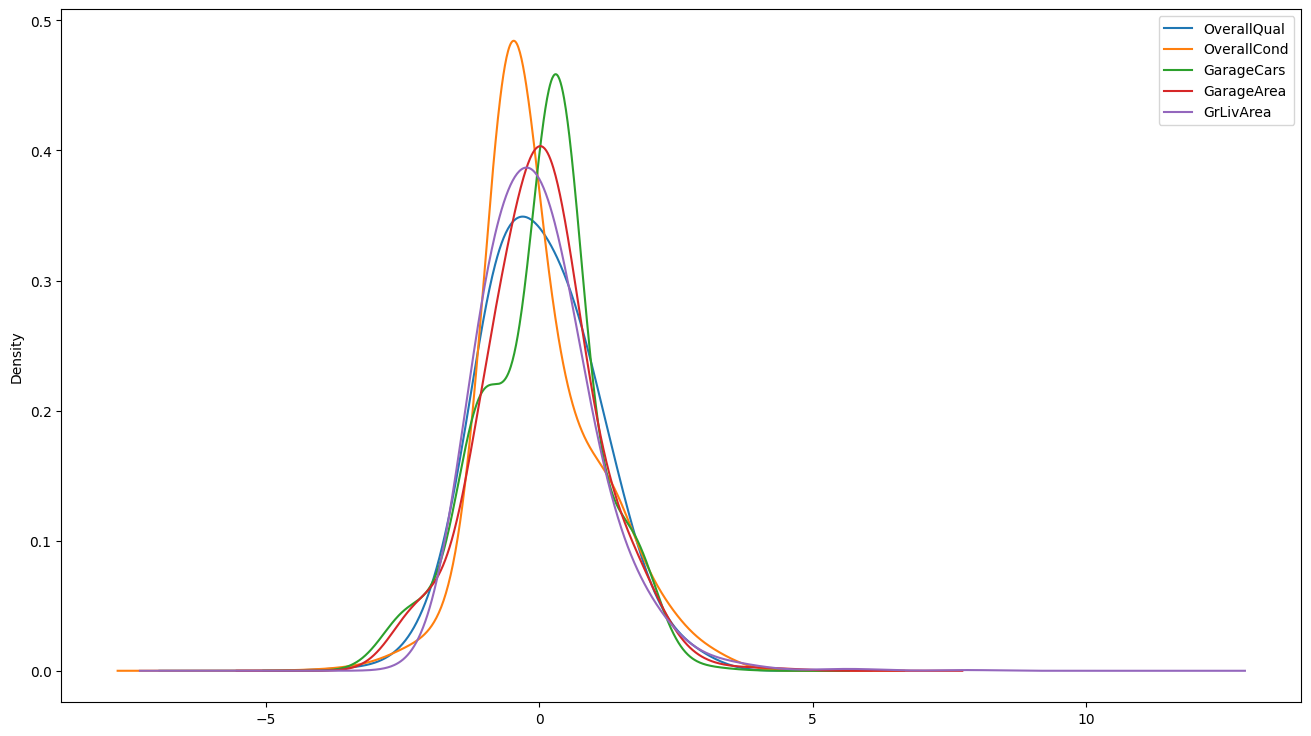

In [15]:
estandarized_df.plot.kde(figsize=(16,9), bw_method=0.5)

In [16]:
standard_scaler

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [17]:
standard_scaler.mean_

array([   6.09931507,    5.57534247,    1.76712329,  472.98013699,
       1515.46369863])

In [18]:
standard_scaler.scale_

array([  1.38252284,   1.11241818,   0.74705904, 213.73160808,
       525.30039356])

> **Ojo 👁️**: Los transformadores no solo _aplican_ una operación matemática, sino que también **aprenden** una distribución. Es por esto que primero deben **entrenarse** antes de transformar. Luego, esta transformación puede aplicarse a nuevos datos.

> **Pregunta ❓**: ¿Qué sucede con las variables que se alejan mucho de ser normales?

In [19]:
px.histogram(df, x='BsmtUnfSF')

### Escalamiento mínimo-máximo

Una buena alternativa al método anterior, es el escalamiento por rango, este tiene la forma:

\begin{equation}
\frac{x_{i} - \min(x)}{\max (x)-\min (x)}
\end{equation}

para $x$ columna a tratar, $x_i$ elemento a transformar. Esta transformación permite hacer que los datos se muevan entre 0 y 1 y puede ser utilizado y la distribución de los datos no normales. 

> **Nota:** este transformador se ve afectado por la presencia de outliers. 

In [20]:
px.histogram(df, 'Fireplaces')

In [21]:
cols_to_scale = ['BsmtUnfSF', 'Fireplaces']

# BsmtUnfSF = Unfinished square feet of basement area
df.loc[:, 'BsmtUnfSF'].plot.hist(backend='plotly')

In [22]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

scaled_data = minmax_scaler.fit_transform(df.loc[:, cols_to_scale])
scaled_data = pd.DataFrame(scaled_data, columns=cols_to_scale)

In [23]:
scaled_data.describe()

,BsmtUnfSF,Fireplaces
count,1460.000000,1460.000000
mean,0.242826,0.204338
std,0.189155,0.214889
min,0.000000,0.000000
25%,0.095462,0.000000
50%,0.204409,0.333333
75%,0.345890,0.333333
max,1.000000,1.000000


In [24]:
scaled_data.plot.hist(backend='plotly', barmode='overlay')

Comprobamos minimos y máximos:

In [25]:
scaled_data.min()

BsmtUnfSF     0.0
Fireplaces    0.0
dtype: float64

In [26]:
scaled_data.max()

BsmtUnfSF     1.0
Fireplaces    1.0
dtype: float64

Si se desea escalar por rango, la mejor práctica es comprender los mínimos y máximos *absolutos* para cada columna. Esto se refiere, a las cotas superiores e inferiores que posee la columna **por definición**. A modo de ejemplo, considere un dataframe con las notas de una asginatura donde se enzeña análisis de datos. Se sabe que la nota máxima en cierto ítem se codifica en una columna y su máximo es en efecto es 7.0, sin embargo el mínimo en dicha columna es 1.5, que es distinto al mínimo natural para dicho item que es 1.0. Esto puede acarrear problemas con datos nuevos, sobretodo si aparece una nota inferior a 1.5. 

> **Ejercicios 📝**

1. Investigue los parámetros que se deben usar para proporcionar escalamiento por rango con valores máximos y mínimos proporcionados explícitamente. 

2. Estudie el transformador `MaxAbsScaler`.

### Outliers

Un outlier es un atípicos que están fuera del rango comun del resto de los datos.

In [27]:
px.histogram(df, x='LotArea', marginal='box')

In [28]:
minmax_scaler = MinMaxScaler()
scaled_data = minmax_scaler.fit_transform(df.loc[:, ['LotArea']])
scaled_data = pd.DataFrame(scaled_data, columns=['LotArea'])
scaled_data.plot.hist(backend='plotly', barmode='overlay')

> **Pregunta:** ¿Qué pasa cuando queremos estandarizar pero tenemos outliers?

Respuesta: La gran mayoría de los datos tienen a quedar en un rango muy acotado. En el caso anterior, hacia la izquierda. 

In [29]:
# media con los todos los datos de LotArea
original = round(df['LotArea'].describe(), 3)
original.name = 'LotArea Original'

# datos presentes solo en el rango intercuantílico
q1 = df['LotArea'].quantile(.25)
q3 = df['LotArea'].quantile(.75)
mask = df['LotArea'].between(q1, q3, inclusive='both')
iqr = df.loc[mask, 'LotArea']
iqr.name ='LotArea Filtro IQR'
iqr = round(iqr.describe(), 3)

Observen las diferencias entre las medias y las desviaciones estándar:

In [30]:
desc = pd.concat([original, iqr], axis=1)
desc

,LotArea Original,LotArea Filtro IQR
count,1460.000,730.000
mean,10516.828,9507.018
std,9981.265,1083.054
min,1300.000,7558.000
25%,7553.500,8636.250
50%,9478.500,9478.500
75%,11601.500,10400.000
max,215245.000,11600.000


Si normalizamos usando estandarización original, cada dato va a ser dividido por 9981, 9 veces más grande que la usando la versión sin outliers usando IQR!

Esto en términos prácticos hará que los datos tiendan a concentrarse mucho más cercanos a la media.

### Transformación Logaritmica

La transformación logarítmica es un método de transformación de datos en el que **se sustituye cada variable x por un log(x + c)**, utilizando un base logaritmica y constante **c** escogida por el analista. Con **este tipo de transformación se reduce o elimina la asimetría de nuestros datos originales**, PERO, para poder utilizar esta transformación es importante que los datos originales deben tener una distribución logarítmica normal. De lo contrario, la transformación logarítmica no funcionará.

$$log(X+c), \, c \in R$$

Si bien esta transformación suele ser una de las más útiles, transformar las variables genera una perdide da interpretabilidad directa en los datos, por esta razón se deben realizar transformaciones para visualizar el impacto de x en su dominio original. Para más información revisar el siguiente [artículo](https://medium.com/@kyawsawhtoon/log-transformation-purpose-and-interpretation-9444b4b049c9).

In [31]:
def log_transform(x):
    return np.log(x + 1)

In [32]:
px.histogram(df['BsmtUnfSF'], marginal='box', barmode='overlay')

In [33]:
log_transformer = log_transform(df['LotArea'])

px.histogram(log_transformer, marginal='box', barmode='overlay')

### Transformación Robusta

Cuando se trabaja con columnas que poseen valores fuera de rango (outliers) las transformaciones anteriores pueden fallar. En este caso, se recomienda utilizar una transformación similar a la estandarización, pero que trabaje sobre la mediana como media y el rango intercuantílico como desviación estándar:

\begin{equation}
\frac{x_i - Q_2(x)}{Q_3(x) - Q_1(x)}
\end{equation}

Donde $IQR = Q_3(x) - Q_1(x)$ es el rango intercuartílico de la columna $x$. 

En otras palabras, por cada ejemplo se sustrae la mediana y se divide por el rango intercuartil 75%- 25%

In [34]:
# Ejemplo para obtener IQR
data = np.array([1, 14, 19, 20, 22, 24, 26, 47])

# Calculamos rango intercurtil
q3, q1 = np.percentile(data, [75 ,25])
q3 - q1

np.float64(6.75)

**Ejemplo**

Aplicaremos esta transformación a la columna LotArea

In [35]:
px.histogram(df['LotArea'])

Se importa el objeto `RobustScaler` y se aplica

In [36]:
from sklearn.preprocessing import RobustScaler

robust_scaler = RobustScaler()

lot_area_standarized = standard_scaler.fit_transform(df[['LotArea']])
robust_scaled_lot_area = robust_scaler.fit_transform(df[['LotArea']])

In [37]:
comparacion = np.concatenate([lot_area_standarized, robust_scaled_lot_area], axis=1)
comparacion = pd.DataFrame(comparacion, columns=['Estandarizacion Común', 'Estandarización Robusta'])

In [38]:
comparacion

,Estandarizacion Común,Estandarización Robusta
0,-0.207142,-0.254076
1,-0.091886,0.030015
2,0.073480,0.437624
3,-0.096897,0.017663
4,0.375148,1.181201
...,...,...
1455,-0.260560,-0.385746
1456,0.266407,0.913167
1457,-0.147810,-0.107831
1458,-0.080160,0.058918


In [39]:
px.histogram(comparacion, marginal='box', barmode='overlay')

Podemos observar como los datos en la estandarización robusta se distribuyen de forma mas amplia que en caso de la estandarización normal.

### Mapeo a distribuciones gaussianas 

Como se mencionó anteriormente, no siempre se cumple la hipótesis de normalidad en las columnas de un dataset, en tal caso, no es una buena idea estandarizar los datos pues puede llevar a problemas al momento de operar con algoritmos que requieren normalidad en su formulación. Existe una familia de transformaciones paramétrica que busca aproximar una distribución arbitraria a una gaussiana, se accede a este tipo de transformaciones por medio de la clase `PowerTransformer`, en esta clase se encuentran 2 transformaciones:

* Box-Cox: Solo puede ser utilizada en datos extrictamente positivos. Viene dada por:

\begin{equation}
x_{i}^{(\lambda)} =
\begin{cases}
\frac{x_{i}^{\lambda}-1}{\lambda} & \text { si } \lambda \neq 0 \\
\ln \left(x_{i}\right) & \text { si } \lambda=0
\end{cases}.
\end{equation}

* Yeo-Johnson dada por: 

\begin{equation}
x_{i}^{(\lambda)}=
\begin{cases}
\left[\left(x_{i} + 1\right)^{\lambda}-1 \right] / \lambda & \text { si } \lambda \neq 0, x_{i} \geq 0 \\
\ln \left(x_{i}+1\right) & \text { si } \lambda=0, x_{i} \geq 0 \\
-\left[\left(-x_{i}+1\right)^{2-\lambda}-1\right] /(2-\lambda) & \text { si } \lambda \neq 2, x_{i}<0 \\
-\ln \left(-x_{i}+1\right) & \text { si } \lambda=2, x_{i}<0
\end{cases}
\end{equation}

En ambos casos, el parámetro $\lambda$ es estimado por máxima verosimilitud.


**BsmtUnfSF** = Metros cuadrados no construidos en el subterraneo.

In [40]:
from sklearn.preprocessing import PowerTransformer

In [41]:
bsmtUnfSF_solo_pos = df.loc[df['BsmtUnfSF'] > 0, ['BsmtUnfSF']]

In [42]:
px.histogram(bsmtUnfSF_solo_pos)

#### Box - Cox

In [43]:
# transformación box-cox

transformer_bc = PowerTransformer(method='box-cox')

df_bc = transformer_bc.fit_transform(bsmtUnfSF_solo_pos)
df_bc = pd.DataFrame(df_bc, columns=['BsmtUnfSF'])


px.histogram(df_bc)

#### Yeo-Johnson

In [44]:
# transformación yeo-johnson
transformer_yj = PowerTransformer(method='yeo-johnson')

df_yj = transformer_yj.fit_transform(bsmtUnfSF_solo_pos)
df_yj = pd.DataFrame(df_yj, columns=['BsmtUnfSF'])

px.histogram(df_yj)

> **Ejercicio 📝**

1. Obtenga los valores de lambda para cada uno de los de métodos revisados.

2. El preprocesamiento por transformación de cuantiles es un método robusto que permite transformar una distribución de datos en una variable uniforme o normal. Permite el reducir el impacto de outliers. Investigue su formulación, ventajas y desventajas, aplique el transformer `QuantileTransformer` en los datos recientemente generados para observar su comportamiento.

### Normalización

Otro método de transformación de datos es la normalización de estos. Esto conisite en un mapeo a la bola cerrada según una norma a elección. Consiste simplemente en dividir los datos por su norma euclidiana l2. En el caso de 3 dimensiones se ve de esta manera:

\begin{equation}
\frac{x_{i}}{\sqrt{x_{i}^{2}+y_{i}^{2}+z_{i}^{2}}}
\end{equation}

El escalado de las entradas a normas unitarias es una operación habitual en la clasificación de textos o la agrupación por clústeres.

**Ejemplo** 

Se estudia como opera este transformador de datos en una visualización:

In [45]:
fig = px.scatter_3d(
    df,
    x='LotArea',
    y='GrLivArea',
    z='GarageArea',
)
fig.show()

Se estudia el impacto de la transformación

In [46]:
from sklearn.preprocessing import Normalizer
cols_to_normalize = ['LotArea','GrLivArea','GarageArea']

normalizer = Normalizer()

normalized_data = normalizer.fit_transform(df.loc[:, cols_to_normalize])
normalized_data = pd.DataFrame(normalized_data, columns=cols_to_normalize)

Finalmente se visualiza

In [47]:
fig = px.scatter_3d(
    normalized_data,
    x='LotArea',
    y='GrLivArea',
    z='GarageArea',
)
fig.show()

Observamos que los datos forman una superficie curva que corresponde a una parte de la esfera unitaria. En otras palabras, esto implica tomar cada punto como un vector y escalarlo para que esté a 1 de distancia del origen, sin cambiar su dirección

> ¿Qué pasa si estandarizamos y normalizamos?

In [48]:
normalizer = Normalizer()
standardizer = StandardScaler()

standardised_data = standardizer.fit_transform(df.loc[:, cols_to_normalize])
normalized_data = normalizer.fit_transform(standardised_data)
normalized_data = pd.DataFrame(normalized_data, columns=cols_to_normalize)

In [49]:
fig = px.scatter_3d(
    normalized_data,
    x='LotArea',
    y='GrLivArea',
    z='GarageArea',
)
fig.show()

### ¿Qué aspectos deberíamos considerar al momento de realizar escalamientos? 😅

Al momento de realizar escalamiento de cualquier tipo deben considerar los siguientes puntos:

- **El escalamiento es una fuente de data leakeage**. ¿Qué es data leakage?, data leakage se produce cuando se utiliza información ajena al conjunto de datos de entrenamiento para crear el modelo.
- **Necesidad de entrenamiento ante variaciones de los datos de entrada**. Muchos de los escalamientos necesitan el cálculo de un estadístico para realizar la transformación, esto implica que si los datos vistos durante el entrenamiento cambian en producción las transformaciones no serán las mejores y necesitarán un reentrenamiento de los datos.

👀 **Spoiler**: Mas tarde en este curso aprenderemos una forma simple para evitar el data-leakage utilizando pipelines.

---

## Codificación de Variables Ordinales

Hasta ahora hemos trabajado con variables numéricas, las cuales si bien deben preprocesarse, pueden ser usadas fácilmente por modelos. Este no es el caso de las variables categóricas, ya que las categorías por defecto no pueden ser entendidas por los modelos de ML.

Dentro de las variables categóricas existen varios tipos. Se puede hacer la siguiente categorización:
- Variables categóricas ordinales: Las categorías tienen un orden preestablecido
- Variables categóricas nominales: Las categorías no tienen orden

Para el manejo de adecuado de variables ordinales,  se recomienda expresar sus valores en función de códigos númericos. El transformer `OrdinalEncoder` permite transformar características categóricas en códigos enteros (números enteros)

Se entrena el codificador

BsmtQual: Evaluates the height of the basement

       Ex	Excellent (100+ inches)	
       Gd	Good (90-99 inches)
       TA	Typical (80-89 inches)
       Fa	Fair (70-79 inches)
       Po	Poor (<70 inches
       NA	No Basement
		
BsmtCond: Evaluates the general condition of the basement

       Ex	Excellent
       Gd	Good
       TA	Typical - slight dampness allowed
       Fa	Fair - dampness or some cracking or settling
       Po	Poor - Severe cracking, settling, or wetness
       NA	No Basement
	
       
HeatingQC: Heating quality and condition

       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       Po	Poor

In [50]:
df['BsmtQual']

Id
1       Gd
2       Gd
3       Gd
4       TA
5       Gd
        ..
1456    Gd
1457    Gd
1458    TA
1459    TA
1460    TA
Name: BsmtQual, Length: 1460, dtype: str

In [51]:
from sklearn.preprocessing import OrdinalEncoder

enc = OrdinalEncoder()

variables_ordinal = df[['BsmtCond', 'BsmtQual','HeatingQC']]

# Se entrena el codificador
ordinales = enc.fit_transform(variables_ordinal.dropna())
pd.DataFrame(ordinales, columns = ['BsmtCond', 'BsmtQual','HeatingQC'])

,BsmtCond,BsmtQual,HeatingQC
0,3.0,2.0,0.0
1,3.0,2.0,0.0
2,3.0,2.0,0.0
3,1.0,3.0,2.0
4,3.0,2.0,0.0
...,...,...,...
1418,3.0,2.0,0.0
1419,3.0,2.0,4.0
1420,1.0,3.0,0.0
1421,3.0,3.0,2.0


In [52]:
variables_ordinal

,BsmtCond,BsmtQual,HeatingQC
Id,,,
1,TA,Gd,Ex
2,TA,Gd,Ex
3,TA,Gd,Ex
4,Gd,TA,Gd
5,TA,Gd,Ex
...,...,...,...
1456,TA,Gd,Ex
1457,TA,Gd,TA
1458,Gd,TA,Ex


Se obtienen las categorías

In [53]:
df.loc[:, ['BsmtCond']]

,BsmtCond
Id,
1,TA
2,TA
3,TA
4,Gd
5,TA
...,...
1456,TA
1457,TA
1458,Gd


In [54]:
enc.categories_

[array(['Fa', 'Gd', 'Po', 'TA'], dtype=object),
 array(['Ex', 'Fa', 'Gd', 'TA'], dtype=object),
 array(['Ex', 'Fa', 'Gd', 'Po', 'TA'], dtype=object)]

> **Pregunta ❓**: ¿Existe algún problema en estas codificaciones?

In [55]:
categories_order = [
    ["Po", "Fa", "TA", "Gd", "Ex"],
    ["Po", "Fa", "TA", "Gd", "Ex"],
    ["Po", "Fa", "TA", "Gd", "Ex"]
]

In [56]:
enc_2 = OrdinalEncoder(categories=categories_order)

ordinales = enc_2.fit_transform(variables_ordinal.dropna())

pd.DataFrame(ordinales, columns = ['BsmtCond', 'BsmtQual','HeatingQC'])

,BsmtCond,BsmtQual,HeatingQC
0,2.0,3.0,4.0
1,2.0,3.0,4.0
2,2.0,3.0,4.0
3,3.0,2.0,3.0
4,2.0,3.0,4.0
...,...,...,...
1418,2.0,3.0,4.0
1419,2.0,3.0,2.0
1420,3.0,2.0,4.0
1421,2.0,2.0,3.0


In [65]:
variables_ordinal

,BsmtCond,BsmtQual,HeatingQC
Id,,,
1,TA,Gd,Ex
2,TA,Gd,Ex
3,TA,Gd,Ex
4,Gd,TA,Gd
5,TA,Gd,Ex
...,...,...,...
1456,TA,Gd,Ex
1457,TA,Gd,TA
1458,Gd,TA,Ex


> **Pregunta ❓**: ¿Codificamos estas variables con `variables_ordinal.dropna()`. Por qué tuvimos que botar los valores faltantes y que se puede hacer en este caso ?

> **Pregunta ❓**: ¿Cómo codificamos las variables que no tienen orden?

## Codificación de Variables Categoricas nominales

Un problema común con la códificación ordinal es que las variables pasan a ser consideradas continuas por algoritmos de machine learning (en especial por la API *estimators* de scikit-learn). Para evitar esto es posible convertir cada categoría en una columna por si sola y asignar un 1 cuando esté presente. 

![One Hot Encoding](https://github.com/MDS7202/MDS7202/blob/main/recursos/2023-01/14-Feature-Engineering-Parte-I/ohe.png?raw=true)
<center>Fuente: https://morioh.com/p/811a5d22bbca </center>

> **Pregunta ❓** ¿Y por qué no podemos convertir cada categoría a un número como con las variables ordinales?

Esto se puede llevar a cabo por medio del transformador ` OneHotEncoder`.

In [57]:
df['Foundation'].unique()

<StringArray>
['PConc', 'CBlock', 'BrkTil', 'Wood', 'Slab', 'Stone']
Length: 6, dtype: str

In [58]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()

cod = ohe.fit_transform(df.loc[:, ['Foundation']])

In [59]:
ohe.categories_

[array(['BrkTil', 'CBlock', 'PConc', 'Slab', 'Stone', 'Wood'], dtype=object)]

In [60]:
pd.DataFrame(cod.toarray(), columns=ohe.categories_)

,BrkTil,CBlock,PConc,Slab,Stone,Wood
0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...
1455,0.0,0.0,1.0,0.0,0.0,0.0
1456,0.0,1.0,0.0,0.0,0.0,0.0
1457,0.0,0.0,0.0,0.0,1.0,0.0
1458,0.0,1.0,0.0,0.0,0.0,0.0


In [61]:
df.loc[:, 'Neighborhood'].unique()

<StringArray>
['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'Mitchel', 'Somerst',  'NWAmes',
 'OldTown', 'BrkSide',  'Sawyer', 'NridgHt',   'NAmes', 'SawyerW',  'IDOTRR',
 'MeadowV', 'Edwards',  'Timber', 'Gilbert', 'StoneBr', 'ClearCr', 'NPkVill',
 'Blmngtn',  'BrDale',   'SWISU', 'Blueste']
Length: 25, dtype: str

In [62]:
# Ahora, con los barrios
ohe.fit_transform(df.loc[:, ['Neighborhood']])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1460 stored elements and shape (1460, 25)>

### Sparse Matrix

Son matrices que contienen muy pocos valores distintos de 0 y estos se encuentran muy dispersos en la matriz.

![](https://www.kdnuggets.com/wp-content/uploads/sparse-matrix.jpg)

In [63]:
import numpy as np
from scipy import sparse

X = np.random.uniform(size=(10000, 10000))  # 100.000.000
X[X < 0.99] = 0
X_csr = sparse.csr_matrix(X)

print(f"Size in bytes of original matrix: {X.nbytes}")
print(
    f"Size in bytes of compressed sparse row matrix: {X_csr.data.nbytes + X_csr.indptr.nbytes + X_csr.indices.nbytes}"
)
print(
    f'Relación: { (X_csr.data.nbytes + X_csr.indptr.nbytes + X_csr.indices.nbytes)/ X.nbytes }'
)

Size in bytes of original matrix: 800000000
Size in bytes of compressed sparse row matrix: 12029960
Relación: 0.01503745


> **Ejercicio 📝**

1. Utilice este transformador en los datos categóricos anteriores. Los resultados serán entregados en formato *sparse* por  lo que tendrá que hacer uso del método `.toarray()` de los arreglos de NumPy.

2. Compare con la función `get_dummies` de pandas.

## Ya pero quiero aprender mas... ¿algo para leer? 🤔

- Para comenzar pueden visualizar con mayor profundidad la documentación de Scikit-Learn enfocada en la extracción de features: https://scikit-learn.org/stable/modules/feature_extraction.html
- Complementar la clase leyendo el capitulo 5 del libro [Designing Machine Learning Systems](https://www.amazon.com/Designing-Machine-Learning-Systems-Production-Ready/dp/1098107969)

- Leer capitulo 1 del libro [Machine Learning Design Patterns: Solutions to Common Challenges in Data Preparation, Model Building, and MLOps](https://www.amazon.com/-/es/Valliappa-Lakshmanan/dp/1098115783/ref=pd_bxgy_img_sccl_1/142-9514380-0202369?pd_rd_w=JQSaa&content-id=amzn1.sym.26a5c67f-1a30-486b-bb90-b523ad38d5a0&pf_rd_p=26a5c67f-1a30-486b-bb90-b523ad38d5a0&pf_rd_r=BJE9WMJ9X1QQMYF4C3EJ&pd_rd_wg=y78Jr&pd_rd_r=6a1994c2-2734-428a-a270-ded23f892987&pd_rd_i=1098115783&psc=1)